<a href="https://colab.research.google.com/github/AdwaiT-ctrl/NN-programming-tutorials/blob/main/Programming_Tutorial_12_CLIP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Programming Tutorial 12: CLIP

```
Course: CSCI 4922/5922 Spring 2026, University of Colorado Boulder
TA: Everley Tseng
Email: Yu-Yun.Tseng@colorado.edu
* AI assistant was used in making this tutorial
```

## Overview

Sections:
- CLIP for image classification

Objectives:
- Learn how to leverage the zero-shot CLIP model on Hugging Face

## Introduction

**CLIP (Contrastive Language-Image Pretraining)** is a model developed by OpenAI that learns to relate images and text by training on a large dataset of image-text pairs. The key idea behind CLIP is to learn a joint embedding space for both images and text such that corresponding image-text pairs are close together in this space, while non-corresponding pairs are far apart. This enables the model to understand both images and text in a unified way.




<img src="https://miro.medium.com/v2/resize:fit:3662/1*tg7akErlMSyCLQxrMtQIYw.png" alt="Illustration of attention mechanism in the paper Attention Is All You Need." width="95%">

*An overview figure of CLIP from "Learning Transferable Visual Models From Natural Language Supervision".*

Pay attention to these components in the model:
- **Image Encoder**: CLIP uses a vision transformer (ViT) or a ResNet as its image encoder. The image is processed into a feature vector that represents the content of the image.
- **Text Encoder**: CLIP uses a Transformer-based model (similar to GPT) as its text encoder. The text is processed into a feature vector that represents the semantic content of the text.
- **Zero-Shot Learning**: One of the key features of CLIP is its zero-shot capability. After pretraining on a large amount of image-text data, CLIP can be used in a zero-shot fashion for tasks like image classification or text-based image retrieval without the need for further task-specific training. It can directly take an image and a textual description (e.g., "cat") and determine whether the description matches the image.



Below, let's use the clip model from Hugging Face to perform zero-shot classification task.

## CLIP Model on Hugging Face

Below, let's follow the [CLIP tutorial](https://huggingface.co/docs/transformers/en/model_doc/clip) on Hugging Face to load the model and make predictions.

There are multiple CLIP configurations available on Hugging Face including [`clip-vit-base-patch16`](https://huggingface.co/openai/clip-vit-base-patch16), [`clip-vit-large-patch32`](https://huggingface.co/openai/clip-vit-base-patch32), and [`clip-vit-large-patch14`](https://huggingface.co/openai/clip-vit-large-patch14). We'll be using the smaller model `clip-vit-base-patch16` for demonstration.

In [ ]:
from transformers import CLIPProcessor, CLIPModel

# Load pre-trained CLIP model and processor
model = CLIPModel.from_pretrained('openai/clip-vit-base-patch16')
processor = CLIPProcessor.from_pretrained('openai/clip-vit-base-patch16')

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch16
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## Experiments

Below, we will use this pretrained CLIP to predict the class for some sample images. To simplify the testing code, let's build a function for generating prediction results based on an input image and a set of input texts.

### Process Input and Predict

- Text Input: For classification, set up prompts for each class, such as `["a photo of a cat", "a photo of a dog", "a photo of a car"]`.
- Image Input: To test the above classes, we have three urls here to test on. You may add your own images or classes.
- Processor: These prompts will be processed separately with an output prediction score for each prompt. Following the tutorial, use `processor` to process the text and the image input.
- Output: Run prediction and apply `softmax` to acquire a probability distribution over the text inputs.

In [ ]:
import torch
from PIL import Image
import requests
from io import BytesIO
import matplotlib.pyplot as plt

def CLIP_probability(image_url, text):
    # Load an image
    response = requests.get(image_url)
    image = Image.open(BytesIO(response.content))
    plt.imshow(image)
    plt.show()

    # Preprocess the image and text inputs
    inputs = processor(text=text, images=image, return_tensors='pt', padding=True)

    with torch.no_grad():
        outputs = model(**inputs)

    # Get the similarity between the image and text
    logits_per_image = outputs.logits_per_image
    probs = logits_per_image.softmax(dim=1)  # Probabilities for each class

    for prompt, prob in zip(text, probs.tolist()[0]):
        print('Prompt: {}, probability: {:.4f}'.format(prompt, prob))

### Predict - Change to Any Image

We will use multiple set of texts to pair with the input image. You may change the list of texts based on the objects in your image:

In [ ]:
text = ['a photo of a cat', 'a photo of a dog', 'a photo of a car']

#### Example 1

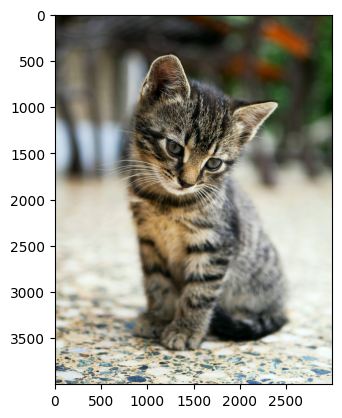

Prompt: a photo of a cat, probability: 0.9978
Prompt: a photo of a dog, probability: 0.0020
Prompt: a photo of a car, probability: 0.0002


In [ ]:
image_url = 'https://images.unsplash.com/photo-1529778873920-4da4926a72c2?fm=jpg&q=60&w=3000&ixlib=rb-4.0.3&ixid=M3wxMjA3fDB8MHxzZWFyY2h8Mnx8Y3V0ZSUyMGNhdHxlbnwwfHwwfHx8MA%3D%3D'
CLIP_probability(image_url, text)

#### Example 2

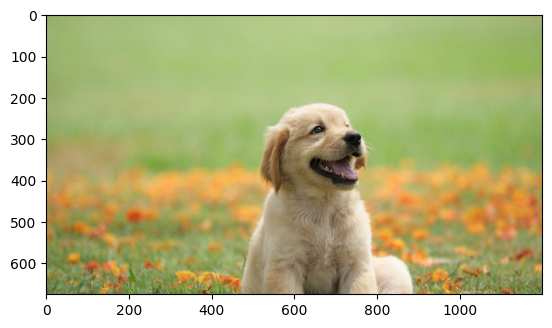

Prompt: a photo of a cat, probability: 0.0010
Prompt: a photo of a dog, probability: 0.9988
Prompt: a photo of a car, probability: 0.0002


In [ ]:
image_url = 'https://hips.hearstapps.com/hmg-prod/images/dog-puppy-on-garden-royalty-free-image-1586966191.jpg?crop=1xw:0.74975xh;center,top&resize=1200:*'
CLIP_probability(image_url, text)

#### Example 3

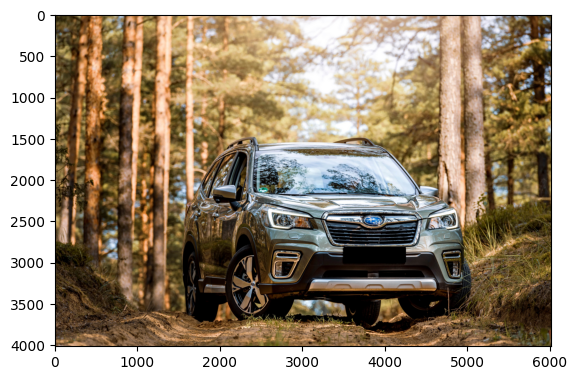

Prompt: a photo of a cat, probability: 0.0000
Prompt: a photo of a dog, probability: 0.0009
Prompt: a photo of a car, probability: 0.9991


In [ ]:
image_url = 'https://cdn.sanity.io/images/n5z5pg8m/production/11f87126853cc061e815f5b300d7f7e5c21cf5ea-6016x4016.jpg'
CLIP_probability(image_url, text)

Feel free to try this with more images by changing the urls to other images.

## Review

The CLIP model understands the relationship between images and text without needing fine-tuning, which highlights the power of zero-shot learning. For practice, you can test CLIP on different images and tasks. These are all practical tasks in real-world applications!


For any questions and discussions regarding this tutorial, attend [TA office hours](https://docs.google.com/spreadsheets/d/1abWD9DJqjEGrCdr8VbZ3aiOhx4vpT1y0-LOoLWgPwZM/edit?usp=sharing) or create a post on [Piazza](https://piazza.com/colorado/spring2026/csci49225922/home) :) See you in the next tutorial!

\- Everley